# Final thesis plots

Clean, publication-quality versions of the main oscillon results, all in one place.
Every panel is rendered inline **and** saved as a PDF (with a PNG mirror) in `GoodFigures/`.

**Conventions (applied to every panel below):**
- One *selection* cell with explicit lists of which parameters to plot.
- One *plot* cell ending in `save_fig(fig, NAME); plt.show()`.

**Index of panels:**
1. Scalar field at $r=0$ vs $t$ and vs shifted $\ln(a)$.
2. Four-panel paper diagnostics (`plot_paper_diagnostics`) for one chosen run.

Further panels will be added on request, following the same pattern.

## 0 — Imports and output directory

In [13]:
import sys, os, re, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from backgrounds.sphericalbackground import FlatSphericalBackground
from bssn.oscillondiagnostic import get_oscillon_diagnostic, plot_paper_diagnostics

DATA_DIR = os.path.join(os.environ.get("VSC_DATA", os.getcwd()), "oscillon_runs")
FIG_DIR  = Path(os.getcwd()) / "GoodFigures"
FIG_DIR.mkdir(exist_ok=True)

print(f"DATA_DIR = {DATA_DIR}")
print(f"FIG_DIR  = {FIG_DIR}")

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs
FIG_DIR  = /vsc-hard-mounts/leuven-user/384/vsc38419/0scillons/February26Oscillons/Feb26/RunningCode/DATA/GoodFigures


## 1 — Publication style and figure-saving helper

In [22]:
plt.rcParams.update({
    "font.family":      "serif",
    "mathtext.fontset": "cm",
    "figure.dpi":       120,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.labelsize":   14,
    "axes.titlesize":   14,
    "xtick.labelsize":  12,
    "ytick.labelsize":  12,
    "legend.fontsize":  11,
    "lines.linewidth":  2.0,
    "axes.linewidth":   1.6,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.minor.width": 0.9,
    "ytick.minor.width": 0.9,
    "xtick.major.size":  5.0,
    "ytick.major.size":  5.0,
    "axes.grid":        True,
    "grid.alpha":       0.3,
})

def save_fig(fig, name):
    """Save fig as both PDF and PNG in GoodFigures/."""
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"  saved {pdf_path.name} and {png_path.name}")

## 2 — Alignment and grid parameters

All runs share the same physical grid and modified-gravity background; alignment shifts each
run's $\ln(a)$ axis so the last crossing of a per-amplitude compactness threshold sits at
`ALIGN_LNA`.

In [15]:
ALIGN_LNA      = 2.0
ALIGN_METHOD   = "last_cross"   # "min_C" or "last_cross"
LNA_MIN_SEARCH = 0.0

C_CROSS_LEVELS = {
    -0.02: 0.02,
    -0.05: 0.04,
    -0.1:  0.06,
    -0.5:  0.125,
}
C_CROSS_DEFAULT = 0.02

LN_A_COMP_MIN = 2.0
LN_A_COMP_MAX = 3.5

scalar_mu = 1
r_max     = 150
min_dr    = 1 / 16
max_dr    = 2
a_mg      = 0.2
b_mg      = 0.4
chi0      = 0.15

## 3 — Alignment helpers

In [16]:
def find_peak_lna(osc, lna_min=0.0):
    """Return ln(a) of the minimum compactness after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    peak = idx[np.argmin(C[idx])]
    return ln_a[peak]

def find_last_crossing_lna(osc, level, lna_min=0.0):
    """Return ln(a) of the last time C crosses `level` (from above) after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    C_sub = C[idx]
    ln_a_sub = ln_a[idx]
    above = C_sub > level
    crossings = np.where(above[:-1] & ~above[1:])[0]
    if len(crossings) == 0:
        return np.nan
    last = crossings[-1]
    frac = (level - C_sub[last+1]) / (C_sub[last] - C_sub[last+1])
    return ln_a_sub[last] * frac + ln_a_sub[last+1] * (1 - frac)

def compactness_in_window(shifted_ln_a, C, lo=LN_A_COMP_MIN, hi=LN_A_COMP_MAX):
    """Mean, min, max, std of C inside [lo, hi] on the *shifted* axis."""
    mask = (shifted_ln_a >= lo) & (shifted_ln_a <= hi)
    if not np.any(mask):
        return np.nan, np.nan, np.nan, np.nan
    c = C[mask]
    return np.mean(c), np.min(c), np.max(c), np.std(c)

def _key_sort(key):
    """Sort key for run-keys that may contain None (e.g. beta=None for linear coupling).

    Maps None -> +inf so linear runs sort after numeric beta values.
    """
    return tuple(float('inf') if v is None else v for v in key)

## 4 — Load all runs at the chosen resolution

Loads every run that matches the loading filters (default: $a_{\rm MG}=b_{\rm MG}=0$, $\Delta r = 1/24$),
computes/loads diagnostics, applies the alignment shift, and also stashes the central scalar field
$\phi(r=0,t)$ so plot 1 doesn't need to reload `solution.npy`.

In [17]:
######## LOADING FILTERS ########
FILTER_A_MG = 0       # None to load all
FILTER_B_MG = 0       # None to load all
FILTER_DR   = 1/24    # None to load all
############################

all_runs = {}   # key = (lgb, mu, beta, amp, width)

for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, "lgb*"))):
    tag = os.path.basename(run_dir)
    if not os.path.exists(os.path.join(run_dir, "solution.npy")):
        continue

    m_lgb = re.search(r"lgb([0-9eE.+-]+)", tag)
    m_mu  = re.search(r"mu([0-9eE.+-]+)", tag)
    m_amp = re.search(r"_amp([0-9eE.+-]+)", tag)
    m_R   = re.search(r"_R([0-9eE.+-]+)", tag)
    if not m_lgb or not m_mu:
        continue
    lgb   = float(m_lgb.group(1))
    mu    = float(m_mu.group(1))
    amp   = float(m_amp.group(1)) if m_amp else -0.02
    width = float(m_R.group(1))   if m_R   else 3.0

    m_a = re.search(r"_a([0-9eE.+-]+)_b", tag)
    m_b = re.search(r"_b([0-9eE.+-]+)_amp", tag)
    tag_a = float(m_a.group(1)) if m_a else 0.2
    tag_b = float(m_b.group(1)) if m_b else 0.4

    m_dr = re.search(r"_dr([0-9eE.+-]+)", tag)
    tag_dr = float(m_dr.group(1)) if m_dr else 0.0625

    if FILTER_A_MG is not None and abs(tag_a - FILTER_A_MG) > 1e-10:
        continue
    if FILTER_B_MG is not None and abs(tag_b - FILTER_B_MG) > 1e-10:
        continue
    if FILTER_DR is not None and abs(tag_dr - FILTER_DR) > 1e-4:
        continue

    m_beta = re.search(r"quadratic_(\d+\.?\d*)", tag)
    beta = float(m_beta.group(1)) if m_beta else 250.0

    if "_linear" in tag:
        coupling = "linear"; beta = None
    elif m_beta:
        coupling = f"quadratic_{int(beta)}"
    else:
        coupling = "quadratic"
        beta = 0.0  # default quadratic uses lambda*phi**2 (beta=0 by our convention)

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t   = np.load(os.path.join(run_dir, "t.npy"))

    matter_i  = ScalarMatter(scalar_mu, mu)
    sv_i      = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(r_max, min_dr, max_dr))
    grid_i    = Grid(spacing_i, sv_i)
    bg_i      = FlatSphericalBackground(grid_i.r)

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
    else:
        params = (lgb, a_mg, b_mg, chi0, coupling)
        osc = get_oscillon_diagnostic(
            sol, t, grid_i, bg_i,
            ScalarMatter(scalar_mu, mu),
            params, surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(diag_path, **osc)

    # Stash central scalar field phi(r=0, t)
    N_grid   = len(grid_i.r)
    NUM_VARS = sol.shape[1] // N_grid
    phi_c    = sol[:, 12 * N_grid].copy()

    if ALIGN_METHOD == "last_cross":
        cross_level = C_CROSS_LEVELS.get(amp, C_CROSS_DEFAULT)
        anchor_lna  = find_last_crossing_lna(osc, level=cross_level, lna_min=LNA_MIN_SEARCH)
    else:
        anchor_lna  = find_peak_lna(osc, lna_min=LNA_MIN_SEARCH)
    shift = ALIGN_LNA - anchor_lna if not np.isnan(anchor_lna) else 0.0
    shifted_ln_a = osc["ln_a"] + shift

    C_mean, C_min, C_max, C_std = compactness_in_window(shifted_ln_a, osc["C"])

    key = (lgb, mu, beta, amp, width)
    all_runs[key] = dict(
        osc=osc, t=t, phi_c=phi_c, tag=tag,
        lgb=lgb, mu=mu, beta=beta, coupling=coupling, amp=amp, width=width,
        shift=shift, shifted_ln_a=shifted_ln_a,
        C_mean=C_mean, C_min=C_min, C_max=C_max, C_std=C_std,
    )

    beta_str = f"beta={int(beta) if beta is not None else 'lin'}" if beta is not None else "linear"
    if np.isnan(C_mean):
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}  "
              f"shift={shift:+.3f}  C: no data in window  ({len(t)} steps)")
    else:
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}  "
              f"shift={shift:+.3f}  C={C_mean:.4e} [{C_min:.4e}, {C_max:.4e}]  ({len(t)} steps)")
    del sol

print(f"\nTotal: {len(all_runs)} run(s) loaded and aligned")

  lgb=  -1.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.538  C=7.1395e-03 [4.3339e-03, 1.4466e-02]  (1000 steps)
  lgb=  -2.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.536  C=7.0535e-03 [4.2847e-03, 1.3609e-02]  (1000 steps)
  lgb=  -3.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.531  C=6.9746e-03 [4.2228e-03, 1.3554e-02]  (1000 steps)
  lgb=  -4.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.526  C=6.8850e-03 [4.1713e-03, 1.3361e-02]  (1000 steps)
  lgb=  -5.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.524  C=6.8001e-03 [4.1293e-03, 1.3226e-02]  (1000 steps)
  lgb=  -6.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.490  C=6.7319e-03 [4.1234e-03, 1.2932e-02]  (1000 steps)
  lgb=  -7.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.480  C=6.6470e-03 [4.0823e-03, 1.2883e-02]  (1000 steps)
  lgb=  -8.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.475  C=6.5698e-03 [4.0308e-03, 1.2720e-02]  (1000 steps)
  lgb=  -9.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.474 

## 5 — Parameter catalogue

Overview of which parameters are available in `all_runs` after filtering.

In [18]:
all_lgb   = sorted(set(k[0] for k in all_runs))
all_mu    = sorted(set(k[1] for k in all_runs))
all_beta  = sorted(set(k[2] for k in all_runs if k[2] is not None))
has_linear = any(k[2] is None for k in all_runs)
all_amp   = sorted(set(k[3] for k in all_runs))
all_width = sorted(set(k[4] for k in all_runs))
all_couplings = sorted(set(d["coupling"] for d in all_runs.values()))

print(f"runs loaded:      {len(all_runs)}")
print(f"lambda_GB values: {all_lgb}")
print(f"mu values:        {all_mu}")
print(f"beta values:      {all_beta}" + ('  (+ linear runs present)' if has_linear else ''))
print(f"amplitude values: {all_amp}")
print(f"width values:     {all_width}")
print(f"couplings:        {all_couplings}")

print("\nLoaded keys (lgb, mu, beta, amp, width):")
header = f"  {'lgb':>6s}  {'mu':>5s}  {'beta':>5s}  {'amp':>6s}  {'R':>4s}  {'coupling':<14s}  {'shift':>7s}  {'C_mean':>10s}"
print(header)
print("  " + "-" * (len(header) - 2))
for k in sorted(all_runs.keys(), key=_key_sort):
    d = all_runs[k]
    beta_s = "lin" if k[2] is None else f"{k[2]:g}"
    cmean  = "nan" if np.isnan(d['C_mean']) else f"{d['C_mean']:.3e}"
    print(f"  {k[0]:>6g}  {k[1]:>5g}  {beta_s:>5s}  {k[3]:>6g}  {k[4]:>4g}  "
          f"{d['coupling']:<14s}  {d['shift']:>+7.3f}  {cmean:>10s}")

runs loaded:      57
lambda_GB values: [-9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
mu values:        [0.08]
beta values:      [0.0]  (+ linear runs present)
amplitude values: [-1.0, -0.5, -0.1, -0.05, -0.02]
width values:     [3.0]
couplings:        ['linear', 'quadratic', 'quadratic_0']

Loaded keys (lgb, mu, beta, amp, width):
     lgb     mu   beta     amp     R  coupling          shift      C_mean
  -----------------------------------------------------------------------
      -9   0.08      0   -0.02     3  quadratic_0      +0.474   6.481e-03
      -8   0.08      0   -0.02     3  quadratic_0      +0.475   6.570e-03
      -7   0.08      0   -0.02     3  quadratic_0      +0.480   6.647e-03
      -6   0.08      0   -0.02     3  quadratic_0      +0.490   6.732e-03
      -5   0.08      0   -0.02     3  quadratic_0      +0.524   6.800e-03
      -4   0.08      0   -0.02     3  quadratic_0      +0.526   6.885e-03
      -3   0.08 

## 6 — `select_runs` helper

One-liner for the per-panel selection cells. Any argument left as `None` matches all values.

In [19]:
def select_runs(lgb=None, mu=None, beta=None, amp=None, width=None, coupling=None):
    """Return list of keys in all_runs whose fields are in the given allowed lists.

    Pass a single value or a list; None = no filter on that dimension.
    """
    def _norm(v):
        if v is None: return None
        return v if isinstance(v, (list, tuple, set)) else [v]

    lgb, mu, beta = _norm(lgb), _norm(mu), _norm(beta)
    amp, width, coupling = _norm(amp), _norm(width), _norm(coupling)

    def _in(x, allowed): return allowed is None or x in allowed

    matches = [
        k for k, d in all_runs.items()
        if _in(k[0], lgb) and _in(k[1], mu) and _in(k[2], beta)
        and _in(k[3], amp) and _in(k[4], width)
        and _in(d["coupling"], coupling)
    ]
    return sorted(matches, key=_key_sort)

## Panel 1 — Scalar field at $r=0$

Left subplot: $\phi(r=0)$ vs simulation time $t\ [1/m]$.<br>
Right subplot: $\phi(r=0)$ vs aligned $\ln(a)$.

Edit `PLOT1_*` below to pick which runs go on the figure.

In [20]:
### --- Panel 1 selection (edit me) ---
PLOT1_KEYS = select_runs(
    lgb   = [-5, 0, 5],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
)
PLOT1_NAME = "phi_center_evolution"

print(f"{len(PLOT1_KEYS)} run(s) selected for Panel 1:")
for k in PLOT1_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"])

3 run(s) selected for Panel 1:
  (-5.0, 0.08, 0.0, -0.02, 3.0)  coupling= quadratic_0
  (0.0, 0.08, 0.0, -0.02, 3.0)  coupling= quadratic
  (5.0, 0.08, 0.0, -0.02, 3.0)  coupling= quadratic_0


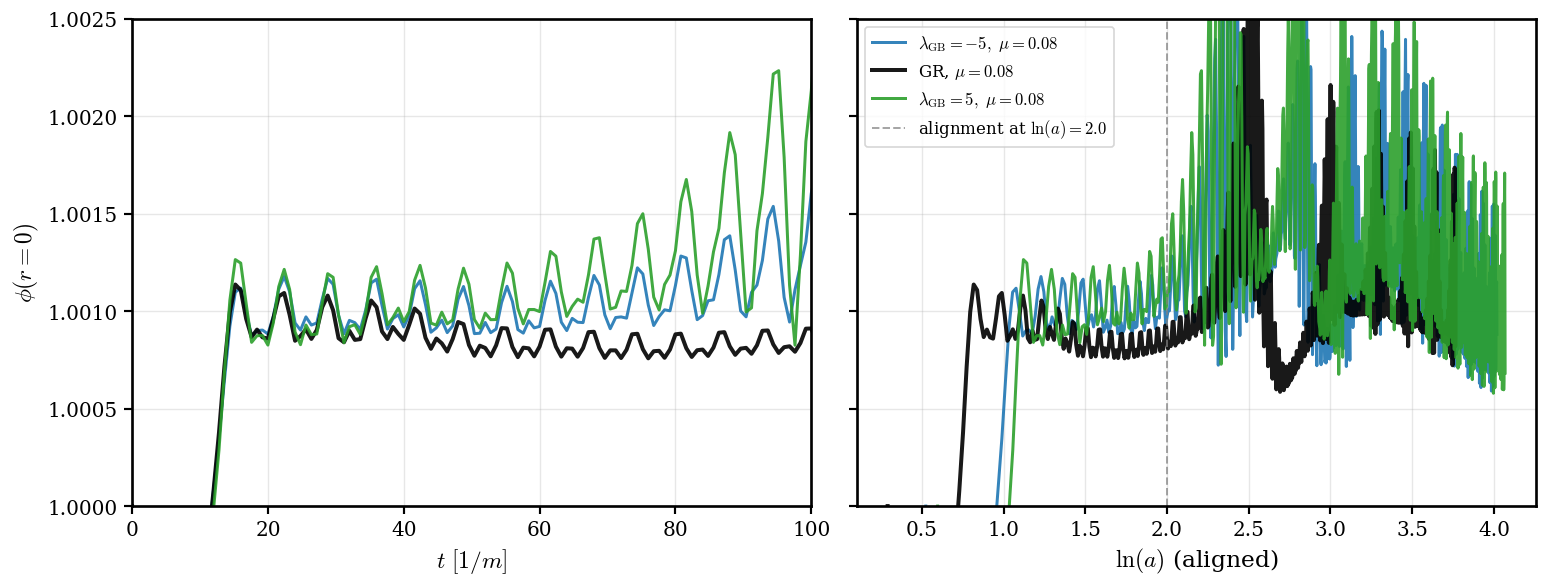

In [26]:
fig, (ax_t, ax_lna) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cmap = plt.cm.tab10

for i, key in enumerate(PLOT1_KEYS):
    data = all_runs[key]
    lgb, mu, beta, amp, width = key

    if lgb == 0.0:
        label = rf"GR, $\mu={mu}$"
    else:
        beta_s = "" if (beta is None or beta == 0) else rf",\ \beta={int(beta)}"
        label  = rf"$\lambda_{{\rm GB}}={lgb:g},\ \mu={mu}{beta_s}$"

    color = "k" if lgb == 0.0 else cmap(i % 10)
    lw    = 2.4 if lgb == 0.0 else 1.8

    ax_t.plot(data["t"], data["phi_c"], color=color, lw=lw, label=label, alpha=0.9)
    ax_lna.plot(data["shifted_ln_a"], data["phi_c"], color=color, lw=lw, label=label, alpha=0.9)

ax_lna.axvline(ALIGN_LNA, color="grey", ls="--", lw=1.2, alpha=0.7,
               label=rf"alignment at $\ln(a)={ALIGN_LNA}$")

ax_t.set_xlabel(r"$t\ [1/m]$")
ax_t.set_ylabel(r"$\phi(r=0)$")
ax_t.set_ylim(1,1.0025)
ax_t.set_xlim(0,100)
#ax_t.set_title("Central scalar field vs physical time")

ax_lna.set_xlabel(r"$\ln(a)$ (aligned)")
#ax_lna.set_title("Central scalar field vs aligned $\\ln(a)$")

ax_lna.legend(fontsize=10, loc="best", frameon=True)
fig.tight_layout()
#save_fig(fig, PLOT1_NAME)
plt.show()

## Panel 2 — Paper diagnostics for one run

The four standard diagnostic panels from `bssn.oscillondiagnostic.plot_paper_diagnostics`
(density contrast, central density, mass & radius, compactness) plotted on the **shifted**
$\ln(a)$ axis for a single chosen run.

Edit `PLOT2_KEY` and `PLOT2_NAME` below.

In [ ]:
### --- Panel 2 selection (edit me) ---
# key format: (lgb, mu, beta, amp, width)
PLOT2_KEY  = (0, 0.08, 0, -0.02, 3.0)
PLOT2_NAME = "paper_diagnostics_GR_amp-0.02"

if PLOT2_KEY not in all_runs:
    print(f"Key {PLOT2_KEY} not found in all_runs.")
    print("Available keys:")
    for k in sorted(all_runs.keys(), key=_key_sort):
        print(" ", k)
else:
    print(f"Selected: {PLOT2_KEY}")
    print(f"  tag      = {all_runs[PLOT2_KEY]['tag']}")
    print(f"  coupling = {all_runs[PLOT2_KEY]['coupling']}")
    print(f"  shift    = {all_runs[PLOT2_KEY]['shift']:+.3f}")

In [ ]:
run = all_runs[PLOT2_KEY]
lgb_i, mu_i, beta_i, amp_i, width_i = PLOT2_KEY

osc_shifted = {**run["osc"], "ln_a": run["shifted_ln_a"]}

fig, axes = plot_paper_diagnostics(osc_shifted)
beta_s = "linear" if beta_i is None else rf"\beta={int(beta_i)}"
fig.suptitle(
    rf"$\lambda_{{\rm GB}}={lgb_i:g},\ \mu={mu_i},\ {beta_s},\ A={amp_i},\ R={width_i}$",
    fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
save_fig(fig, PLOT2_NAME)
plt.show()

---
## Further panels

Future panels follow the same two-cell pattern:

- **Selection cell** — set parameter lists and a `*_NAME` string used for the PDF filename.
- **Plot cell** — build the figure, then `save_fig(fig, NAME); plt.show()` so it is shown
  inline and saved to `GoodFigures/NAME.pdf` (with a `.png` mirror).